In [ ]:
import numpy as np         # библиотека для матриц и математики
import pandas as pd        # библиотека для работы с табличками
from scipy import stats    # модуль для работы со статистикой

# библиотеки для визуализации и картинок
import matplotlib.pyplot as plt
import seaborn as sns

## Задача 1: скучная разминка (25 баллов)

__[5 баллов]__ Создайте диагональную матрицу $5\times5$ с диагональными элементами 1, 2, 3, 4 и 5.

- Найдите её след с помощью библиотечных функций.
- Найдите обратную к ней матрицу.

In [ ]:
a = np.arange(1, 6)
diagm = np.diag(a)

# след матрицы
print('След матрицы равен', np.trace(diagm))

# обратная матрица
print('Обратная матрица:', np.linalg.inv(diagm), sep = '\n')

След матрицы равен 15
Обратная матрица:
[[1.         0.         0.         0.         0.        ]
 [0.         0.5        0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.        ]
 [0.         0.         0.         0.25       0.        ]
 [0.         0.         0.         0.         0.2       ]]


__[5 баллов]__ сгенерируйте случайную матрицу $X$ размера $4\times5$

- Найдите определитель подматрицы матрицы $X$, расположенной на пересечении 2 и 3 строки и 1 и 2 столбца; считаем, что строки и столбцы нумеруются с единицы (используйте slicing!). Такой определитель называется **минором** матрицы $X$.
- Найдите произведение $X^TX$, его определитель и след.

In [ ]:
np.random.seed(3)
X = np.random.uniform(0, 2, size = (4, 5))

print('Минор матрицы X:', np.linalg.det(X[1:3, 0:2]))

Минор матрицы X: 1.6228177944059605


In [ ]:
X2 = np.dot(X.T, X)
print('Матрица X^T * X:', X2, sep = '\n')
print('Определитель X2:', np.linalg.det(X2))
print('След:', np.trace(X2))

Матрица X^T * X:
[[5.82692435 2.12170412 2.78232058 1.95598099 4.60959969]
 [2.12170412 2.90606694 2.16793264 2.00657834 4.02635319]
 [2.78232058 2.16793264 3.44512426 1.93972414 4.08834019]
 [1.95598099 2.00657834 1.93972414 1.63344285 3.09909438]
 [4.60959969 4.02635319 4.08834019 3.09909438 6.48518911]]
Определитель X2: 1.8552033666954854e-15
След: 20.296747507633118


На паре мы говорили, что использования циклов (и самописных вычислений в целом) в python лучше по возможности избегать и важно уметь находить способы делать всё библиотечными средствами.

В следующих трёх заданиях нельзя пользоваться циклами вообще, а также конструкциями `map` и `reduce` и им подобными; вместо этого постарайтесь свести всё к матричным операциям из `numpy` (но, опять же, не `np.vectorize` или чему-то подобному). Чтобы убедиться, что получилось именно то, что нужно, напишите собственные тесты со случайными матрицами.

**[5 баллов]** Напишите функцию `prod_and_sq_sum(A)`, вычисляющую произведение и сумму квадратов диагональных элементов квадратной матрицы `A`.

In [ ]:
def prod_and_sq_sum(A):
    diagA = np.diag(A)
    powA = np.power(diagA, 2)
    dotA = np.prod(powA)
    sumA = np.sum(powA)
    return dotA, sumA

A = np.arange(16).reshape(4,4)
print(prod_and_sq_sum(A))

B = np.array([[1, 2, 3], [2, 5, 6], [6, 7, 4]])
print(prod_and_sq_sum(B))

(0, 350)
(400, 42)


**[5 баллов]** Напишите функцию `get_diag(A,B)`, принимающую две квадратных матрицы `A` и `B` одного размера и возвращающую вектор диагональных элементов произведения `AB`, не вычисляя произведение целиком.

In [ ]:
def get_diag(A,B):
  C = A * B.T
  return np.sum(C, axis = 1)

In [ ]:
A = np.array([[1, 2, 4], [6, 4, 7], [5, 7, 1]])
B = np.array([[3, 8, 6], [2, 7, 3], [9, 3, 8]])
print(get_diag(A, B) == np.diag(A.dot(B)))

D = np.array([[1, 2, 4, 7], [6, 4, 7, 3], [5, 7, 1, 1], [8, 5, 3, 0]])
F = np.array([[3, 5, 8, 6], [1, 0, 9, 4], [9, 8, 4, 2], [1, 3, 5, 6]])
print(get_diag(D, F) == np.diag(D.dot(F)))

[ True  True  True]
[ True  True  True  True]


## Задача 2: про удачу и нашу жизнь (25 баллов)

Задача была вдохновлена [вот этим видео.](https://www.youtube.com/watch?v=3LopI4YeC4I)

Люди часто недооценивают роль случайности в своей жизни. Им кажется, что если они прокачают свои навыки и отдадутся полностью работе, они обязательно достигнут успеха. Люди забывают, что удача тоже важна. Иногда слишком.

Пусть у нас в выборке есть $10000$ кандидатов в космонавты. Из них только $10$ человек пройдут все испытания и приступят к тренировкам. Отбор в космонавты на $95\%$ зависит от навыков кандидата и на $5\%$ от его удачливости. Навыки и удачливость не зависят друг от друга.

__а) [5 баллов]__  Сгенерируйте навык каждого кандидата из равномерного распределения на отрезке $[0; 1]$. По аналогии сгенирируйте удачливость каждого кандидата. Итоговую величину, по которой будет производиться отбор в космонавты, рассчитайте по формуле:

$$
\text{score} = 0.95 \cdot \text{skill} + 0.05 \cdot \text{luck}.
$$

Повторите эту симуляцию $10^4$ раз. Оцените среднее значение удачливости тех, кто стал космонавтом. Постройте гистограмму для распределения удачи среди тех, кто стал космонавтом.

**Hint:** обратите внимание на функцию `np.argpartition`. Она поможет вам сделать код проще. Также обратите внимание, что в пунктах б) и в) нужно переиспользовать результаты симуляций из пункта а). Иначе код будет работать слишком долго.

Среднее значение удачливости космонавтов = 0.9326499346287704


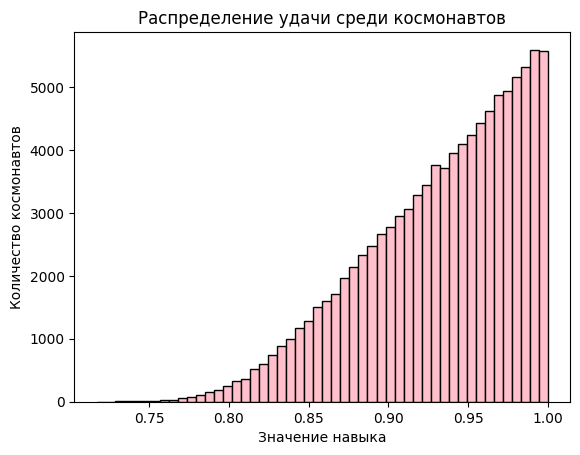

In [ ]:
np.random.seed(3)
n = 10 ** 4
skill = stats.uniform(0, 1).rvs((n, n))
luck = stats.uniform(0, 1).rvs((n, n))
score = 0.95 * skill + 0.05 * luck

col = np.argsort(-score)
row = np.tile(np.arange(n).reshape(-1, 1), n)
luck_win = luck[row, col][:, :10]
mean_luck = np.mean(luck_win)
print('Среднее значение удачливости космонавтов =', mean_luck)

plt.hist(luck_win.reshape(1, -1)[0], bins = 50, color = 'pink', edgecolor='black')
plt.xlabel('Значение навыка')
plt.ylabel('Количество космонавтов')
plt.title('Распределение удачи среди космонавтов')
plt.show()

**Вывод**: По гистограмме видно, что у большей части отобранных космонавтов удача выше 90%; примерно у 40% космонавтов удача выше 95%. Несмотря на маленький вес удачи (5%) в критерии отбора космонавтов, она играет бОльшую роль, чем кажется поначалу из-за веса. Даже если навыки идеально развиты, человек с низкой удачей вряд ли сможет стать космонавтом.

__б) [5 баллов]__  Отберите космонавтов по навыкам, `skill`. Оцените с помощью симуляций, на сколько в среднем человек топ кандидатов по `skill` пересекается с топом по `score`.

In [ ]:
skill_sort = np.argsort(-skill)
score_sort = np.argsort(-score)
skill_top = skill_sort[:, :10]
score_top = score_sort[:, :10]

#следующий кусок решения взяла отсюда: https://stackoverflow.com/questions/19731022/efficiently-find-row-intersections-of-two-2-d-numpy-arrays

ar = np.hstack((skill_top, score_top))
ar.sort(axis = 1)
ar2 = np.sum(ar[:, 1:] == ar[:, :-1], axis = 1)

print('В среднем человек топ кандидатов по skill пересекается с топом по score на', np.mean(ar2) , 'человек')

В среднем человек топ кандидатов по skill пересекается с топом по score на 1.8386 человек


__в) [5 баллов]__ А что будет, если мы будем отбирать больше космонавтов?

Для каждого $n$ от $10$ до $500$ с шагом в $10$ сделайте процедуру отбора в космонавты топ-$n$ кандидатов по `skill` и по `score`. Посчитайте, на сколько в среднем процентов отличаются эти топы. Изобразите получившуюсья зависимость на графике. По оси абсцисс отложите $n$, по оси ординат процент пересечения.

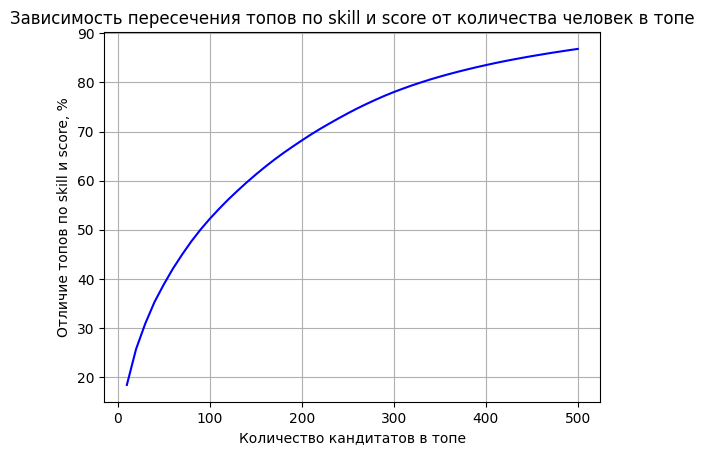

In [ ]:
x = np.array([])
percent_diff = np.array([])
y = np.array([])

for i in range(10, 501, 10):
    skill_top1 = skill_sort[:, :i]
    score_top1 = score_sort[:, :i]
    arr = np.hstack((skill_top1, score_top1))
    arr.sort(axis = 1)
    percent_y = 100 * np.sum(arr[:, 1:] == arr[:, :-1], axis = 1) / i
    percent_y_mean = np.mean(percent_y)
    percentdif = np.mean(100 - percent_y)
    x = np.append(x, i)
    y = np.append(y, percent_y_mean)
    percent_diff = np.append(percent_diff, percentdif)

plt.plot(x, y, color = 'blue')
plt.xlabel('Количество кандитатов в топе')
plt.ylabel('Отличие топов по skill и score, %')
plt.title('Зависимость пересечения топов по skill и score от количества человек в топе')
plt.grid(True)
plt.show()

**Вывод:** С увеличением количества человек в топе (n) растет пересечение между людьми, которые входят в топ по score и людьми в топе по skill.

Чем больше мы берем людей, тем ниже порог прохождения отбора по score. То есть при маленьких n бОльшую роль играет удача, чем при больших, так как при более низком пороговом значении score с большей вероятностью в топ попадут люди с высоким skill, но с маленьким luck, соответственно, больше совпадений топов по score и skill.



__г) [5 баллов]__ Сделайте выводы из проделанных рассчётов.

__Ответ:__ : При отборе 10 кандидатов среднее значение удачливости = 0.93, и в топе нет никого со значением luck ниже примерно 0.7, а пересечение топ-10 по skill и топ-10 по score совпадает лишь на 18%. Даже если удача вносит небольшой вклад в итоговую оценку, она может существенно повлиять на отбор по этой оценке: даже если скилы развиты до 1, итог будет 0,95, что может быть недостаточно при маленьких n.

Однако при увеличении количества отбираемых кандидатов снижается порог по score, а также среднее значение luck среди топа, поэтому кандидаты с высоким skill могут побороться за место в космонавты.

> Повод ли это грустить? Конечно же, нет. Если вы попытались схватиться за одну из возможностей и у вас ничего не вышло, забудьте об этом. Не впадайте в депрессию, продолжайте пытаться. В мире есть столько возможностей, которые можно упустить. Обидно будет, если вы не попробуете ещё. Рано или поздно удача вам улыбнётся ❤️❤️❤️

Давайте попробуем понять, когда именно она вам улыбнётся.

__д) [4 балла]__ Юра хочет стать космонавтом. У него довольно хорошо развиты навыки. Юра входит в $1\%$ лучших, его `score = 0.99` (Юра прокачал свои навыки до 0.99 и вообще не полагается на удачу). С какой вероятностью Юра станет космонавтом?

In [ ]:
scoreYura = 0.99
score_top_value = -np.sort(-score, axis = 1)[:, :10]
min_top = np.min(score_top_value, axis = 1)
p = np.sum(min_top < scoreYura) / len(min_top)
print('Юра станет космонавтом с вероятностью', p)

Юра станет космонавтом с вероятностью 0.3923


## Задача 3: парадокс лифта (20 баллов)

[Райан Гослинг](https://www.youtube.com/watch?v=2jT71iFvpSM), [Стив Роджерс](https://www.youtube.com/watch?v=hLUdF8cjzyA) и [группа Radiohead](https://www.youtube.com/watch?v=QBGaO89cBMI) катаются на лифте.

В здании 30 этажей и лобби (нулевой этаж). Лифт только один и работает очень медленно. Он останавливается на каждом этаже по пути наверх, а затем на каждом этаже по пути вниз. Перемещение между этажами и ожидание пассажиров занимает минуту. Если лифт стартует с нулевого этажа в 8 утра, он в 08:30 доезжает до 30 и к 9 утра возвращается на первый этаж.

Проведите $10^4$ экспериментов и с их помощью ответьте на следующие вопросы:

__а) [5 баллов]__   Райан Гослинг в случайное время подходит к лифту на 3 этаже и ждёт его. Оцените вероятность того, что лифт приедет к Райану сверху.

In [ ]:
np.random.seed(3)
n = 10 ** 4
# лифт стартует в 8:00 с 0 этажа => на 3 этаж снизу он подъезжает в 03 минуты каждого часа, а сверху - в 57 минут каждого часа
# нам без разницы, в какой час приходит Гослинг, важны лишь минуты, поэтому сгенерирую 10**4 минут
# (без разницы Гослинг подойдет в 8:33 или 11:33, время ожидания и направление лифта будет то же)
ryan_time = stats.uniform(0,60).rvs(n) # минуты, в которые приходит Гослинг
begin = 3
end = 57
up = np.sum((ryan_time > 3) & (ryan_time < 57)) # сверху на 3 этаж лифт подъедет между 03 и 57 минутами
print('Вероятность того, что лифт приедет к Райану сверху =', up / n)

Вероятность того, что лифт приедет к Райану сверху = 0.9042


__б) [5 баллов]__ Группа Radiohead в случайное время подходит к лифту на 25-ом этаже и ждёт его. Оцените вероятность того, что лифт приедет к группе Radiohead сверху.

In [ ]:
np.random.seed(4)
# по той же логике, на 25 этаж лифт подъедет между 25 и 35 минутами
radiohead_time = stats.uniform(0,60).rvs(n) # минуты, в которые приходит группа
begin1 = 25
end1 = 35
up1 = np.sum((radiohead_time > 25) & (radiohead_time < 35))
print('Вероятность того, что лифт приедет к группе сверху =', up1 / n)

Вероятность того, что лифт приедет к группе сверху = 0.1583


__в) [5 баллов]__  Постройте гистограммы времени ожидания лифта для Райана Гослинга и группы Radiohead. Похожи ли визуально распределения на нормальные? Насколько сильно они отличаются друг от друга?

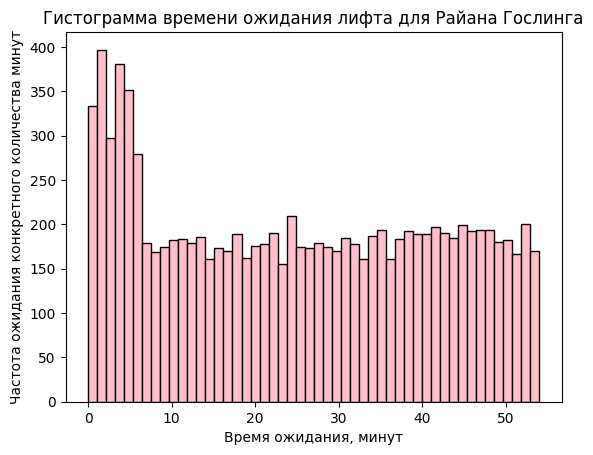

In [ ]:
# райан
ryan_wait = (57 - ryan_time) * ((ryan_time > 3) & (ryan_time <= 57)) + (3 - ryan_time) * (ryan_time <= 3) + (60 - ryan_time + 3)*(ryan_time > 57)
plt.hist(ryan_wait, bins = 50, color = 'pink', edgecolor='black')
plt.xlabel('Время ожидания, минут')
plt.ylabel('Частота ожидания конкретного количества минут')
plt.title('Гистограмма времени ожидания лифта для Райана Гослинга')
plt.show()

**Вывод:** С большей частотой время ожидания Гослингом лифта равняется ~ 0-6 минут, 7-54 минуты встречается с примерно одинаковой, но меньшей частотой (меньше примерно в 2 раза).

Время прихода Гослинга распределено равномерно, значит, Гослинг равновероятно приходит в какой то момент времени. Однако, чтобы ждать 7-54 минут, Гослинг должен прийти в 4-51 минут (на каждую минуту ожидания свое время прихода); чтобы ждать 0-6 минут, Гослинг может прийти в 58-59, 00-03 минуты или в 52-57 минут (на каждую минуту ожидания по два возможных времени прихода).

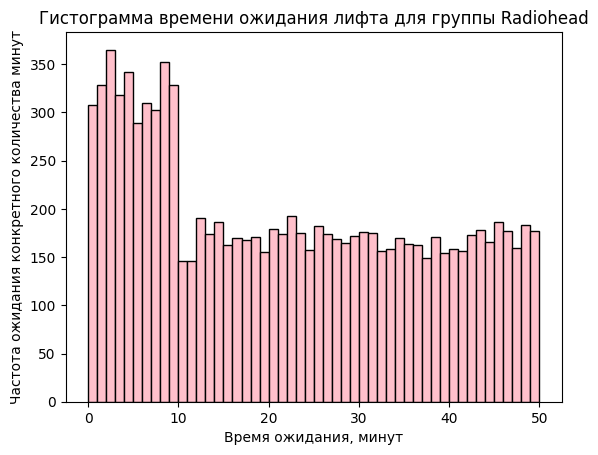

In [ ]:
# radiohead
radiohead_wait = (25 - radiohead_time) * (radiohead_time <= 25) + (35 - radiohead_time) * ((radiohead_time > 25) & (radiohead_time <= 35)) + (60 - radiohead_time + 25) * (radiohead_time > 35)
plt.hist(radiohead_wait, bins = 50, color = 'pink', edgecolor='black')
plt.xlabel('Время ожидания, минут')
plt.ylabel('Частота ожидания конкретного количества минут')
plt.title('Гистограмма времени ожидания лифта для группы Radiohead')
plt.show()

**Вывод:** У Radiohead частота ожидания 0-10 минут примерно в два раза больше частоты ожидания 11-50 минут. Объяснение такое же, как у Гослинга: на ожидание 0-10 минут приходится время прихода 16-25 минут и 26-35 минут (по два момента прихода), а на остальные по одному (00 - 16 и 35-59 минут).

Визуально распределения не похожи на нормальные распределение. Между собой схожи тем, что есть промежутки времени ожидания, которые встречаются чаще. Это происходит из-за того, что лифт едет не только вверх или только вниз, а делает "разворот".

__г) [5 баллов]__ У Стива Роджерса куча свободного времени и он катается на лифте весь день. Нарисуйте для Стива два графика:

- В первом по оси абсцисс отложите этаж, с которого стартует Стив, а по оси ординат отложите оценку вероятности того, что лифт придёт сверху.
- В первом по оси абсцисс отложите этаж, с которого стартует Стив, а по оси ординат среднее время ожидания лифта.

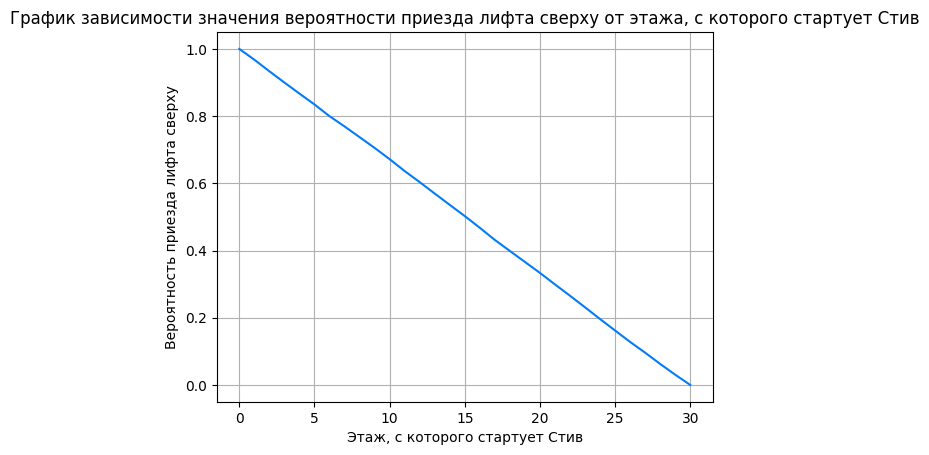

In [ ]:
np.random.seed(5)
stiv_time = stats.uniform(0, 60).rvs(n)
# если стив на этаже x, то лифт, идущий снизу, останавливается в x минут каждого часа, сверху - в (60 - x) мин
# значит сверху приедет, если Стив пришел между x и (60 - x) минутами
x1 = np.arange(31)
y1 = np.sum((stiv_time > x1.reshape(-1, 1)) & (stiv_time < 60 - x1.reshape(-1, 1)), axis = 1) / n

plt.plot(x1, y1, color = '#047cf7')
plt.xlabel('Этаж, с которого стартует Стив')
plt.ylabel('Вероятность приезда лифта сверху')
plt.title('График зависимости значения вероятности приезда лифта сверху от этажа, с которого стартует Стив')
plt.grid(True)
plt.show()

**Вывод:** С первым и последним этажом все понятно: лифт не может спуститься ниже 0 этажа, поэтому приезжает только сверху (с вероятностью 1), и выше 30 этажа не может забраться, поэтому туда приезжает только снизу (то есть нулевая вероятность приезда сверху).

С увеличением номера этажа вероятность приезда сверху лифта снижается, так как снижается количество этажей выше текущего, а значит, меньше вариантов, где может находиться лифт, чтобы он приехал снизу.

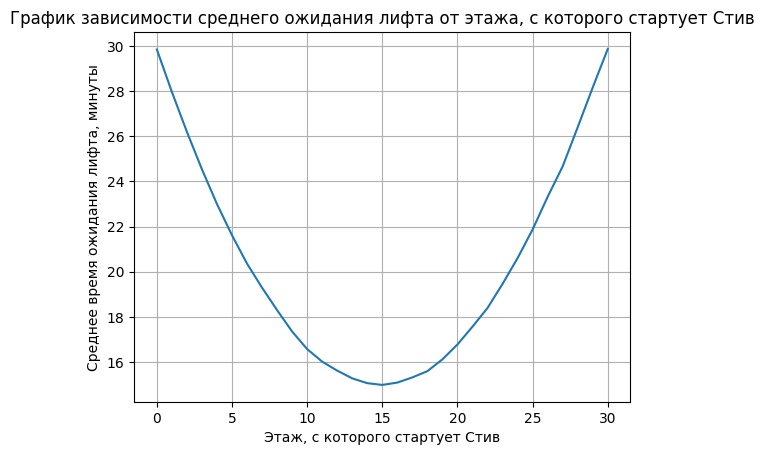

In [ ]:
x2 = np.arange(31)
x2_col = x2.reshape(-1, 1)
stiv_wait = (60 - x2_col - stiv_time) * ((stiv_time > x2_col) & (stiv_time <= 60 - x2_col)) + (x2_col - stiv_time) * (stiv_time <= x2_col) + (60 - stiv_time + x2_col) * (stiv_time > 60 - x2_col)
y2 = np.mean(stiv_wait, axis = 1)

plt.plot(x2, y2)
plt.xlabel('Этаж, с которого стартует Стив')
plt.ylabel('Среднее время ожидания лифта, минуты')
plt.title('График зависимости среднего ожидания лифта от этажа, с которого стартует Стив')
plt.grid(True)
plt.show()

**Вывод:** Как я писала ранее в примере с Гослингом и группой, различное количество минут ожидания лифта встречается с большей частотой.

Так, если этаж с номером $x$, лифт останавливается на этом этаже в $x$ и $60 - x$ минут. До 15 этажа время ожидания лифта, которое "удваивает" частоту времени ожидания - это минуты от 0 до $x$ и от $60 - x$ до 59. Чем выше этаж, тем больше этих "сдвоенных" интервалов, поэтому время ожидания лифта снижается.

На 15 этаже равновероятно нужно ждать лифт снизу 15 минут или сверху 15 минут, поэтому среднее время ожидания - 15 минут.

Если этаж выше 15, то время ожидания лифта, которое "удваивает" частоту - это минуты от 30 до $30 - x$. Чем выше этаж, тем меньше "сдвоенных" интервалов, тем больше среднее время ожидания.

Поэтому получилась такая параболка ☺

Как думаете, будет ли наблюдаться что-то похожее в реальной жизни? Попробуйте понаблюдать за лифтом у себя дома и в офисе. На каком этаже вы живёте/работаете? Выполняется ли для вас [парадокс лифта?](https://en.wikipedia.org/wiki/Elevator_paradox)

⚡ у меня нет лифта, пешочком на 6 этаж((( в целом этот парадокс можно увидеть, если нет сильно мешающих факторов (о которых сказано в википедии)

## Задача 4: паровозики (30 баллов)

От станции Ромашково друг за другом в одном направлении отходит $100$ паровозиков с интервалом в одну минуту. Стартовые скорости паровозиков -- независимые, равномерные на отрезке $[0;1]$ случайные величины. Когда более быстрый паровозик догоняет более медленный, он снижает свою скорость до скорости догнанного паровозика.

Через достаточно длинный интервал времени паровозики разобьются на несколько групп и далее число групп меняться не будет. Назовём это число групп финальным. Проведите $1000$ симуляций и найдите ответы на следующие вопросы:

__а) [5 баллов]__  Какова вероятность того, что пятый паровозик -- лидер очередной группы?

In [ ]:
np.random.seed(12)

trains_speed = stats.uniform(0,1).rvs((1000, 100)) # скорость: км/мин

# если считать, что паровозики разом выезжают с "интервалом" в минуту (как написали в чатике)
# => пятый паровозик является лидером только в том случае, если впереди него нет более медленных паровозиков (иначе он догонит кого-нибудь и уже не будет лидером)

p_leader = np.sum(np.all(trains_speed[:, :4] > trains_speed[:, 4:5], axis = 1)) / 1000
print('Вероятность того, что пятый паровозик - лидер очередной группы =', p_leader)

Вероятность того, что пятый паровозик - лидер очередной группы = 0.218


__б) [5 баллов]__ На сколько финальных групп в среднем разбиваются паровозики?

In [ ]:
a = 1
while a != 0:
  a = np.max(np.diff(trains_speed))
  k = np.argmax(np.diff(trains_speed), axis = 1)
  rows = np.arange(1000).reshape(-1, 1)
  cols = k.reshape(-1, 1)
  trains_speed[rows, cols + 1] = trains_speed[rows, cols]
group_count = np.sum(trains_speed[:, 1:] != trains_speed[:, :-1], axis = 1) + 1
print('В среднем паровозики разбиваются на', np.mean(group_count), 'групп')


В среднем паровозики разбиваются на 5.277 групп
